/home/cihat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


=== DATA SETUP ===
Loaded lifted states shape: (1955, 77)
Total time steps: 1955
Total lifted dimensions: 77

=== TRAIN / FORECAST SPLIT ===
Z_train shape: (1862, 77)
Z1_train shape: (1861, 77)
Z2_train shape: (1861, 77)
Z_future_true shape: (93, 77)

=== KOOPMAN TRAINING ===
Koopman operator K shape: (77, 77)

=== FORECASTING ===
Z_forecast shape: (93, 77)
Forecasted time indices:
From raw index 1862 to 1954

=== ERROR SUMMARY FOR NEXT 100 FORECASTED STEPS ===
a:
  RMSE = 5.899541e+01
  MAE  = 4.730960e+01
e:
  RMSE = 1.240572e-05
  MAE  = 9.242858e-06
i:
  RMSE = 5.448033e-06
  MAE  = 4.702450e-06
omega:
  RMSE = 1.074754e-02
  MAE  = 7.952031e-03
raan:
  RMSE = 5.161337e-06
  MAE  = 4.336379e-06
m:
  RMSE = 1.145172e-02
  MAE  = 8.633577e-03

=== KOOPMAN SPECTRUM ANALYSIS ===
Total Eigenvalues: 77
Max Eigenvalue: 1.00035 + 0.00000j
Max Eigenvalue Magnitude: 1.00035


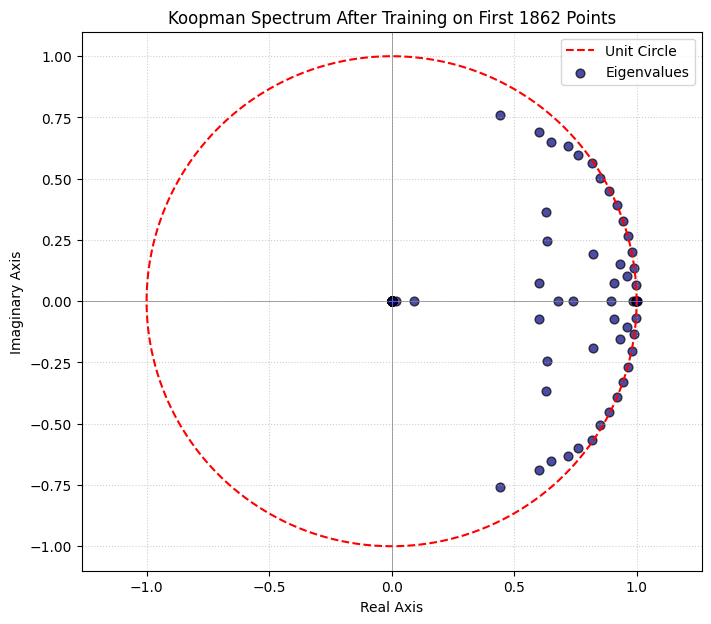

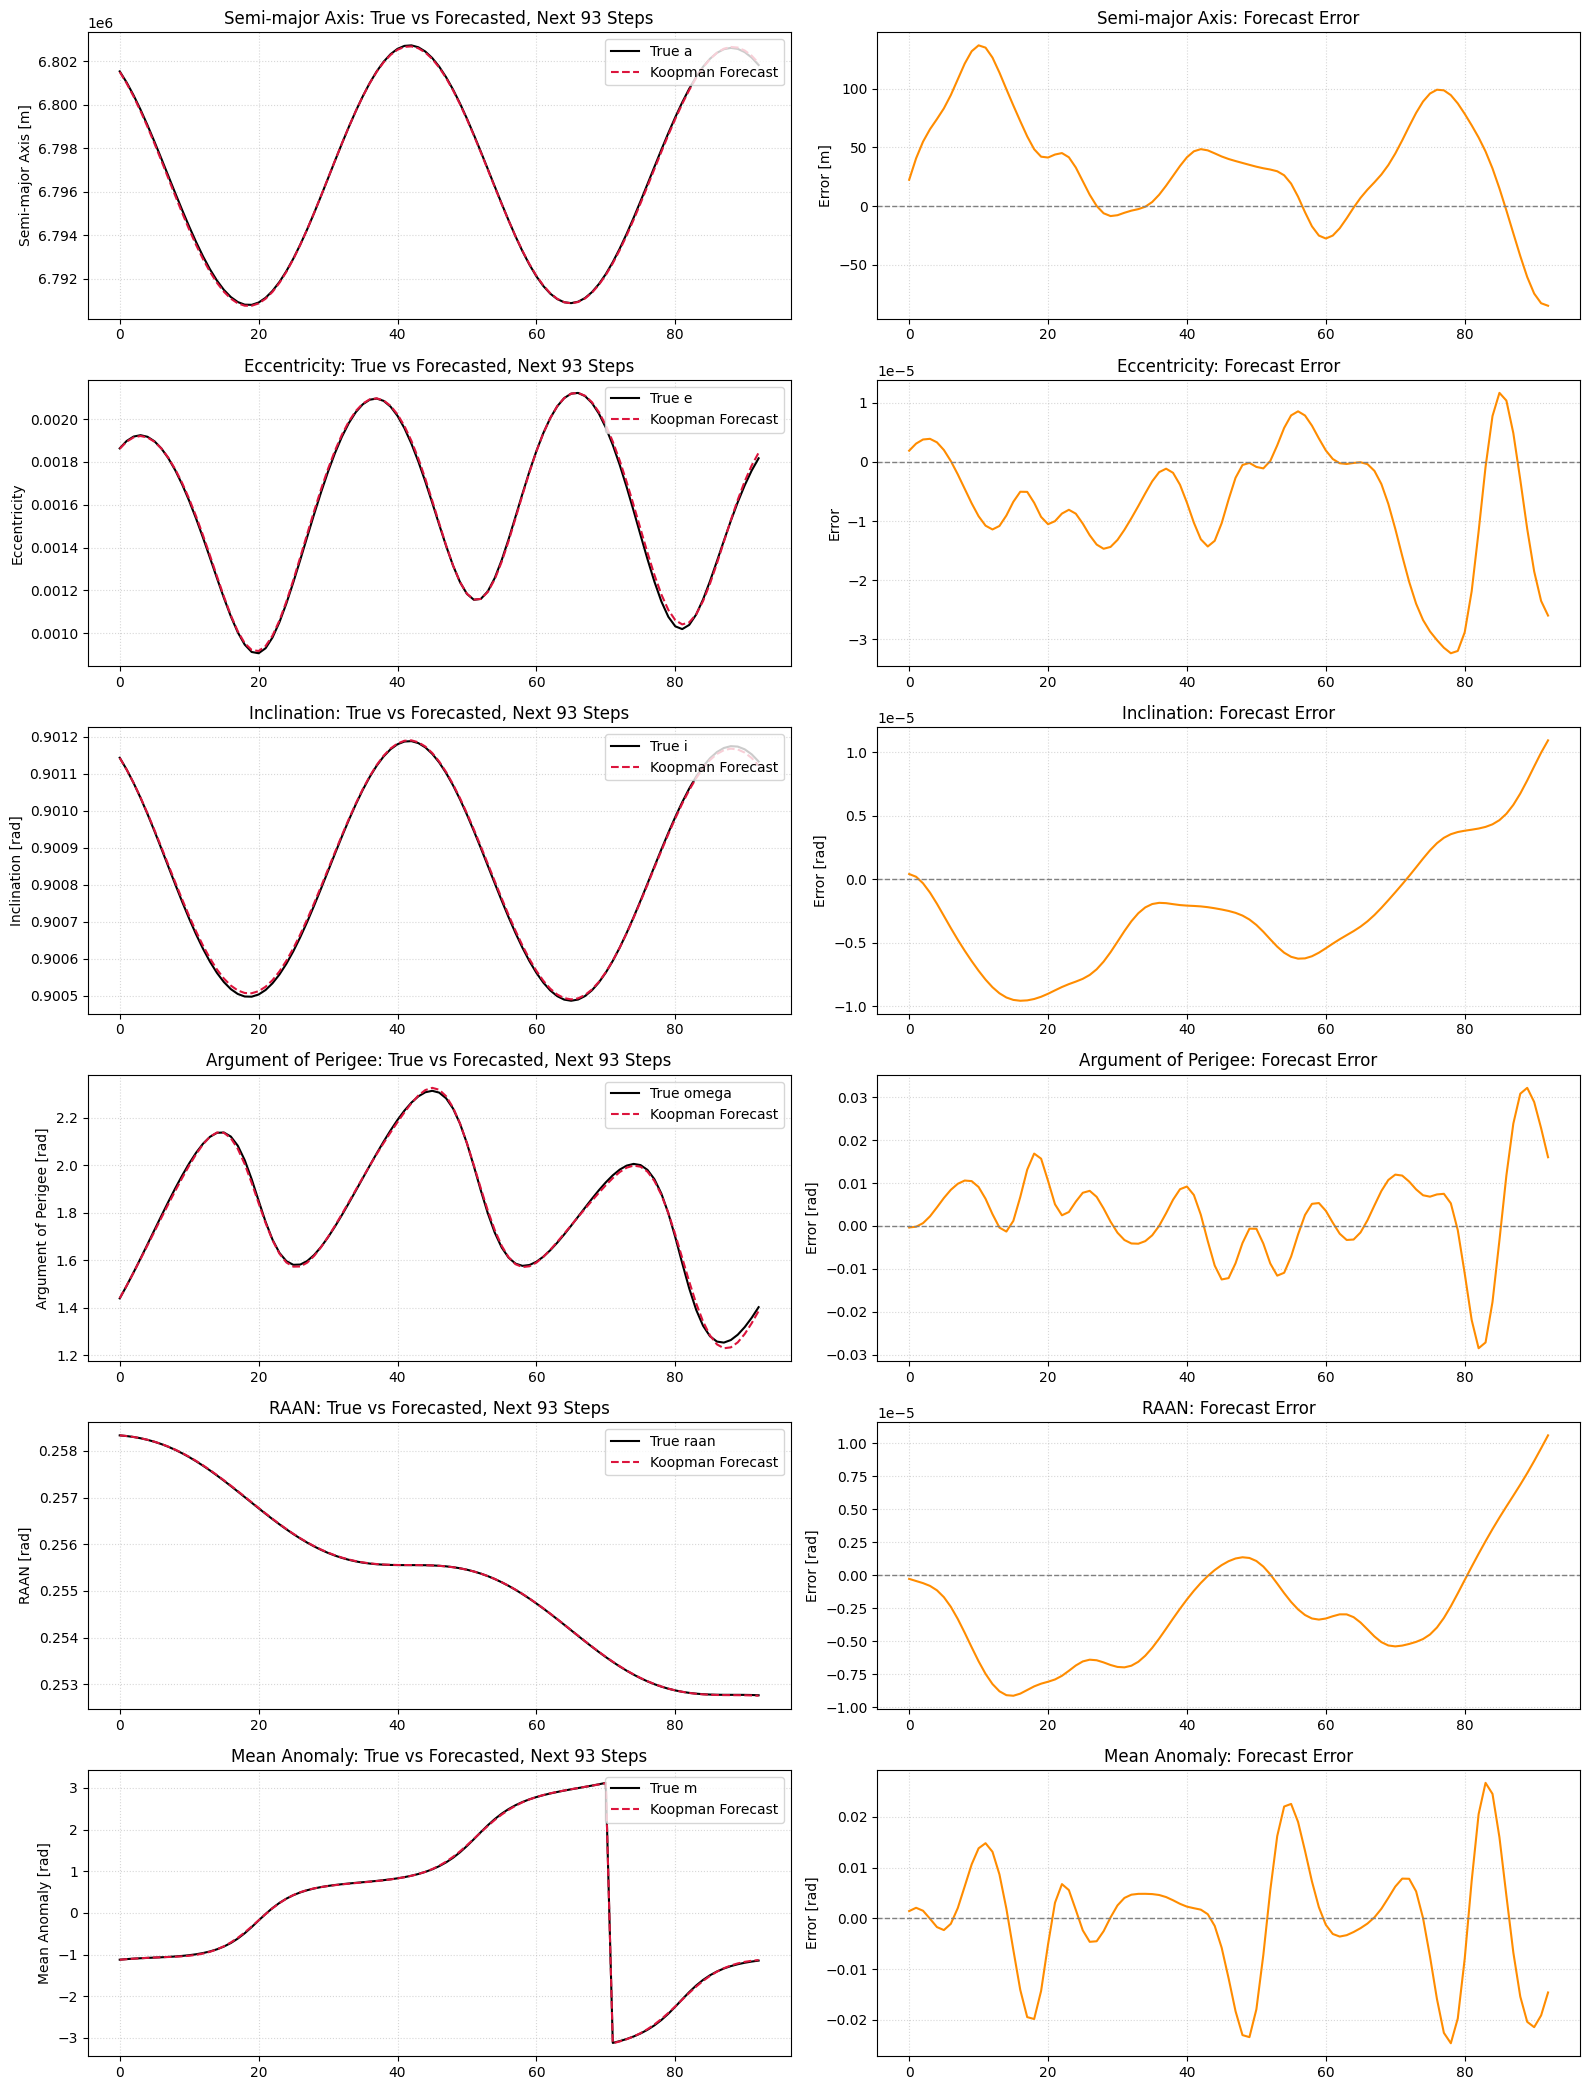

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

try:
    df_raw = pd.read_csv("raw_orbit_data.csv")
    df_lifted = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Missing data file: {e}. Ensure both 'raw_orbit_data.csv' and "
        "'lifted_orbit_data.csv' are in your working directory."
    )

#Z = df_lifted.values
state_cols = [c for c in df_lifted.columns if c != 't']
Z = df_lifted[state_cols].values
n_samples, n_dim = Z.shape

print("=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples}")
print(f"Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. SETTINGS: TRAIN FIRST 1000, PREDICT NEXT 100
# ==============================================================================


MU_EARTH = 3.986004418e14

t_0 = df_raw['t_hours'].iloc[0]
t_1 = df_raw['t_hours'].iloc[1]
delta_t_hours = t_1 - t_0
delta_t_seconds = delta_t_hours * 3600

a_initial = df_raw['a'].iloc[0] 
orbital_period_seconds = 2 * np.pi * np.sqrt((a_initial**3) / MU_EARTH)

steps_per_orbit = int(np.round(orbital_period_seconds / delta_t_seconds))

desired_orbits = 1


N_forecast = desired_orbits * steps_per_orbit
N_train = n_samples - N_forecast 


if n_samples < N_train + N_forecast:
    raise ValueError(
        f"Not enough data. You need at least {N_train + N_forecast} samples, "
        f"but you only have {n_samples}."
    )


# ==============================================================================
# 3. SCALER FOR INVERSE TRANSFORM
# ==============================================================================

# IMPORTANT:
# This scaler must be fitted in the SAME WAY as in your lifting code.
# If your lifting code used all raw data, use df_raw[['a', 'e']].
# If your lifting code used only training data, use df_raw.iloc[:N_train][['a', 'e']].

scaler_ae = MinMaxScaler(feature_range=(-1, 1))
scaler_ae.fit(df_raw[['a', 'e']])

# For a cleaner train/test protocol, you may instead use:
# scaler_ae.fit(df_raw.iloc[:N_train][['a', 'e']])


# ==============================================================================
# 4. SPLIT DATA
# ==============================================================================

# First 1000 lifted states are used for EDMD training
Z_train = Z[:N_train]

# The next 100 lifted states are kept only for comparison
Z_future_true = Z[N_train:N_train + N_forecast]

# For EDMD, we need pairs:
# Z(k)     -> Z(k+1)
# Z1_train -> Z2_train

Z1_train = Z_train[:-1]
Z2_train = Z_train[1:]

print("=== TRAIN / FORECAST SPLIT ===")
print(f"Z_train shape: {Z_train.shape}")
print(f"Z1_train shape: {Z1_train.shape}")
print(f"Z2_train shape: {Z2_train.shape}")
print(f"Z_future_true shape: {Z_future_true.shape}\n")


# ==============================================================================
# 5. TRAIN KOOPMAN OPERATOR USING RIDGE EDMD
# ==============================================================================

model = Ridge(alpha=1e-7, fit_intercept=False)
model.fit(Z1_train, Z2_train)

K = model.coef_

print("=== KOOPMAN TRAINING ===")
print(f"Koopman operator K shape: {K.shape}\n")


# ==============================================================================
# 6. RECURSIVE FORECASTING FOR NEXT 100 STEPS
# ==============================================================================

# Start from the last known training state:
# This is Z at time index 999.
z_current = Z_train[-1].copy()

Z_forecast = []

for step in range(N_forecast):
    # Predict next lifted state:
    # z(k+1) = K z(k)
    # Because sklearn gives K as model.coef_,
    # row-vector form is: z_next = z_current @ K.T
    z_next = z_current @ K.T

    Z_forecast.append(z_next)

    # Use prediction as the next input
    z_current = z_next.copy()

Z_forecast = np.array(Z_forecast)

print("=== FORECASTING ===")
print(f"Z_forecast shape: {Z_forecast.shape}")
print("Forecasted time indices:")
print(f"From raw index {N_train} to {N_train + N_forecast - 1}\n")


# ==============================================================================
# 7. UNLIFT FORECASTED VALUES TO RAW ORBITAL ELEMENTS
# ==============================================================================

# True raw values for the future 100 steps
true_raw_future = df_raw.iloc[N_train:N_train + N_forecast].copy().reset_index(drop=True)

# Your convention:
# column 0 of lifted data is probably constant 1
# columns 1:7 are:
# ['a', 'e', 'i', 'omega', 'raan', 'v']

# pred_raw_future = pd.DataFrame(
#     Z_forecast[:, 1:7],
#     columns=['a', 'e', 'i', 'omega', 'raan', 'm']
# )

# pred_raw_future = pd.DataFrame(
#     Z_forecast[:, 1:7],
#     columns=['a', 'e', 'i', 'omega', 'raan', 'm']
# )


pred_raw_future = pd.DataFrame()

# a, e directly from lifted columns
pred_raw_future['a'] = Z_forecast[:, state_cols.index('a')]
pred_raw_future['e'] = Z_forecast[:, state_cols.index('e')]

# inverse scale a and e
pred_raw_future[['a', 'e']] = scaler_ae.inverse_transform(
    pred_raw_future[['a', 'e']]
)

# inclination can stay direct
pred_raw_future['i'] = Z_forecast[:, state_cols.index('i')]

# angles recovered from sin/cos features, not direct angle columns
pred_raw_future['omega'] = np.arctan2(
    Z_forecast[:, state_cols.index('sin_1omega')],
    Z_forecast[:, state_cols.index('cos_1omega')]
)

pred_raw_future['raan'] = np.arctan2(
    Z_forecast[:, state_cols.index('sin_1raan')],
    Z_forecast[:, state_cols.index('cos_1raan')]
)

pred_raw_future['m'] = np.arctan2(
    Z_forecast[:, state_cols.index('sin_1m')],
    Z_forecast[:, state_cols.index('cos_1m')]
)

# # Inverse transform a and e
# pred_raw_future[['a', 'e']] = scaler_ae.inverse_transform(
#     pred_raw_future[['a', 'e']]
# )

angles = ['i', 'omega', 'raan', 'm']


# ==============================================================================
# 8. COMPUTE ERRORS
# ==============================================================================

errors = pd.DataFrame()

for col in ['a', 'e', 'i', 'omega', 'raan', 'm']:

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values

    if col in angles:
        # Angle-aware error
        errors[col] = np.arctan2(
            np.sin(true_vals - pred_vals),
            np.cos(true_vals - pred_vals)
        )
    else:
        errors[col] = true_vals - pred_vals


print("=== ERROR SUMMARY FOR NEXT 100 FORECASTED STEPS ===")
for col in ['a', 'e', 'i', 'omega', 'raan', 'm']:
    rmse = np.sqrt(np.mean(errors[col].values ** 2))
    mae = np.mean(np.abs(errors[col].values))

    print(f"{col}:")
    print(f"  RMSE = {rmse:.6e}")
    print(f"  MAE  = {mae:.6e}")

print()


# ==============================================================================
# 9. OPTIONAL: KOOPMAN SPECTRUM
# ==============================================================================

eigvals, _ = np.linalg.eig(K)

magnitudes = np.abs(eigvals)
max_idx = np.argmax(magnitudes)
max_eigval = eigvals[max_idx]
max_magnitude = magnitudes[max_idx]

print("=== KOOPMAN SPECTRUM ANALYSIS ===")
print(f"Total Eigenvalues: {len(eigvals)}")
print(f"Max Eigenvalue: {max_eigval.real:.5f} + {max_eigval.imag:.5f}j")
print(f"Max Eigenvalue Magnitude: {max_magnitude:.5f}")

plt.figure(figsize=(8, 7))
theta = np.linspace(0, 2 * np.pi, 200)

plt.plot(
    np.cos(theta),
    np.sin(theta),
    'r--',
    linewidth=1.5,
    label='Unit Circle'
)

plt.scatter(
    eigvals.real,
    eigvals.imag,
    color='navy',
    alpha=0.7,
    edgecolors='k',
    s=40,
    label='Eigenvalues'
)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.title(f"Koopman Spectrum After Training on First {N_train} Points")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.axis("equal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig("lifting-iss/kökler.png", dpi=300, bbox_inches='tight')
plt.show()


# ==============================================================================
# 10. PLOT TRUE VS FORECASTED NEXT 100 STEPS
# ==============================================================================

feature_names = {
    'a': {
        'title': 'Semi-major Axis',
        'unit': 'm',
        'error_unit': 'm'
    },
    'e': {
        'title': 'Eccentricity',
        'unit': '-',
        'error_unit': '-'
    },
    'i': {
        'title': 'Inclination',
        'unit': 'rad',
        'error_unit': 'rad'
    },
    'omega': {
        'title': 'Argument of Perigee',
        'unit': 'rad',
        'error_unit': 'rad'
    },
    'raan': {
        'title': 'RAAN',
        'unit': 'rad',
        'error_unit': 'rad'
    },
    'm': {
        'title': 'Mean Anomaly',
        'unit': 'rad',
        'error_unit': 'rad'
    }
}

fig, axes = plt.subplots(
    len(feature_names),
    2,
    figsize=(16, 3.5 * len(feature_names))
)

for idx, col in enumerate(feature_names.keys()):

    name = feature_names[col]['title']
    unit = feature_names[col]['unit']
    error_unit = feature_names[col]['error_unit']

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values
    error_vals = errors[col].values

    true_vals = true_raw_future[col].values
    pred_vals = pred_raw_future[col].values
    error_vals = errors[col].values

    # Left: True vs Forecasted
    ax_comp = axes[idx, 0]
    ax_comp.plot(
        true_vals,
        label=f"True {col}",
        color="black",
        linewidth=1.5
    )

    ax_comp.plot(
        pred_vals,
        "--",
        label="Koopman Forecast",
        color="crimson",
        linewidth=1.5
    )

    ax_comp.set_title(f"{name}: True vs Forecasted, Next {N_forecast} Steps")
    

    if unit == '-':
        ax_comp.set_ylabel(name)
    else:
        ax_comp.set_ylabel(f"{name} [{unit}]")

    ax_comp.grid(True, linestyle=":", alpha=0.5)
    ax_comp.legend(loc="upper right")

    # Right: Error
    ax_err = axes[idx, 1]
    ax_err.plot(
        error_vals,
        color="darkorange",
        linewidth=1.5
    )

    ax_err.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax_err.set_title(f"{name}: Forecast Error")
    
    if unit == '-':
        ax_err.set_ylabel("Error")
    else:
        ax_err.set_ylabel(f"Error [{unit}]")

    ax_err.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("lifting-iss/19-liftind_with_cos_5omega*(e*sin_6m)-(78-feature).png", dpi=300, bbox_inches='tight')
plt.show()

In [2]:
# ==============================================================================
# 0. OREKIT INSTALLATION AND SETUP
# ==============================================================================

# First, install orekit if not already installed
import subprocess
import sys
import os

def install_orekit():
    """Install orekit package if not already installed."""
    try:
        import orekit
        print("✓ Orekit package already installed")
        return True
    except ImportError:
        print("Installing orekit package...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "orekit"])
            print("✓ Orekit package installed successfully")
            return True
        except Exception as e:
            print(f"✗ Failed to install orekit: {e}")
            print("Please install manually with: pip install orekit")
            return False

def setup_orekit_data():
    """Download and setup Orekit data files."""
    import urllib.request
    import zipfile
    
    orekit_data_dir = "orekit-data"
    
    if os.path.exists(orekit_data_dir):
        print(f"✓ Orekit data directory already exists: {orekit_data_dir}")
        return True
    
    print("Downloading Orekit data files...")
    url = "https://gitlab.orekit.org/orekit/orekit-data/-/archive/master/orekit-data-master.zip"
    zip_path = "orekit-data-master.zip"
    
    try:
        # Download the zip file
        print(f"  Downloading from: {url}")
        urllib.request.urlretrieve(url, zip_path)
        print("  Download complete")
        
        # Extract the zip file
        print("  Extracting files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(".")
        
        # Rename the extracted directory
        if os.path.exists("orekit-data-master"):
            os.rename("orekit-data-master", orekit_data_dir)
        
        # Clean up zip file
        os.remove(zip_path)
        
        print(f"✓ Orekit data files extracted to: {orekit_data_dir}")
        return True
        
    except Exception as e:
        print(f"✗ Failed to setup Orekit data: {e}")
        print("Please manually download from:")
        print("https://gitlab.orekit.org/orekit/orekit-data/-/archive/master/orekit-data-master.zip")
        print("Extract the contents to a folder named 'orekit-data' in your working directory")
        return False

def check_java():
    """Check if Java is installed."""
    try:
        subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT)
        print("✓ Java is installed")
        return True
    except:
        print("⚠ Java not found! Orekit requires Java.")
        print("Please install Java from: https://www.java.com/download/")
        return False

# ==============================================================================
# SETUP OREKIT
# ==============================================================================

print("=== OREKIT SETUP ===")
print("Checking prerequisites...")

# Check Java
java_installed = check_java()

# Install Orekit package
orekit_installed = install_orekit()

# Setup Orekit data
data_setup = setup_orekit_data()

if not all([java_installed, orekit_installed, data_setup]):
    print("\n⚠ WARNING: Some prerequisites are missing.")
    print("The code will fallback to numpy implementation.")
    print("For full Orekit functionality, please address the issues above.\n")
else:
    print("\n✓ Orekit setup complete!\n")

# ==============================================================================
# NOW IMPORT ALL REQUIRED MODULES
# ==============================================================================

# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import Orekit libraries (will work if setup was successful)
try:
    from java.io import File
    from orekit import JArray
    from org.orekit.data import DataContext, DataProvidersManager, DirectoryCrawler
    from org.orekit.time import AbsoluteDate, TimeScalesFactory
    from org.orekit.frames import FramesFactory
    from org.orekit.orbits import KeplerianOrbit, PositionAngleType
    from org.orekit.utils import PVCoordinates
    print("✓ Orekit modules imported successfully")
except ImportError as e:
    print(f"⚠ Warning: Could not import Orekit modules: {e}")
    print("Will use numpy fallback")
    # Define dummy variables for Orekit to avoid errors
    File = None
    JArray = None
    DataContext = None
    DataProvidersManager = None
    DirectoryCrawler = None
    AbsoluteDate = None
    TimeScalesFactory = None
    FramesFactory = None
    KeplerianOrbit = None
    PositionAngleType = None
    PVCoordinates = None

print("\n=== CONTINUING WITH MAIN CODE ===\n")



=== OREKIT SETUP ===
Checking prerequisites...
✓ Java is installed
Installing orekit package...
Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement orekit (from versions: none)
ERROR: No matching distribution found for orekit


✗ Failed to install orekit: Command '['/usr/bin/python3', '-m', 'pip', 'install', 'orekit']' returned non-zero exit status 1.
Please install manually with: pip install orekit
✗ Failed to setup Orekit data: HTTP Error 404: Not Found
Please manually download from:
https://gitlab.orekit.org/orekit/orekit-data/-/archive/master/orekit-data-master.zip
Extract the contents to a folder named 'orekit-data' in your working directory

⚠ WARNING: Some prerequisites are missing.
The code will fallback to numpy implementation.
For full Orekit functionality, please address the issues above.

⚠ Warning: Could not import Orekit modules: No module named 'java'
Will use numpy fallback

=== CONTINUING WITH MAIN CODE ===



Orekit/Java kütüphaneleri bulunamadı: No module named 'orekit'

Falling back to pure numpy implementation...
Using pure numpy ECI conversion

=== CONVERTING TO CARTESIAN COORDINATES (ECI FRAME) ===
Converting true orbital elements...
  Progress: 0/93
  Progress: 50/93
Converting predicted orbital elements...
  Progress: 0/93
  Progress: 50/93

✓ Conversion complete!
  True positions shape: (93, 3)
  Predicted positions shape: (93, 3)
  Frame: ECI (EME2000)
=== CARTESIAN ERROR SUMMARY (ECI FRAME) ===

Position Errors (meters) in ECI:
  x: RMSE = 52977.76 m, MAE = 38545.25 m, Max = 138584.58 m
  y: RMSE = 35952.92 m, MAE = 25787.09 m, Max = 89397.23 m
  z: RMSE = 47048.07 m, MAE = 33568.67 m, Max = 134351.09 m
  Magnitude: RMSE = 79452.99 m, MAE = 63171.84 m, Max = 183604.06 m

Velocity Errors (m/s) in ECI:
  vx: RMSE = 64.2859 m/s, MAE = 46.2359 m/s, Max = 175.0511 m/s
  vy: RMSE = 41.9846 m/s, MAE = 30.1923 m/s, Max = 112.4404 m/s
  vz: RMSE = 46.0006 m/s, MAE = 34.0212 m/s, Max = 114.

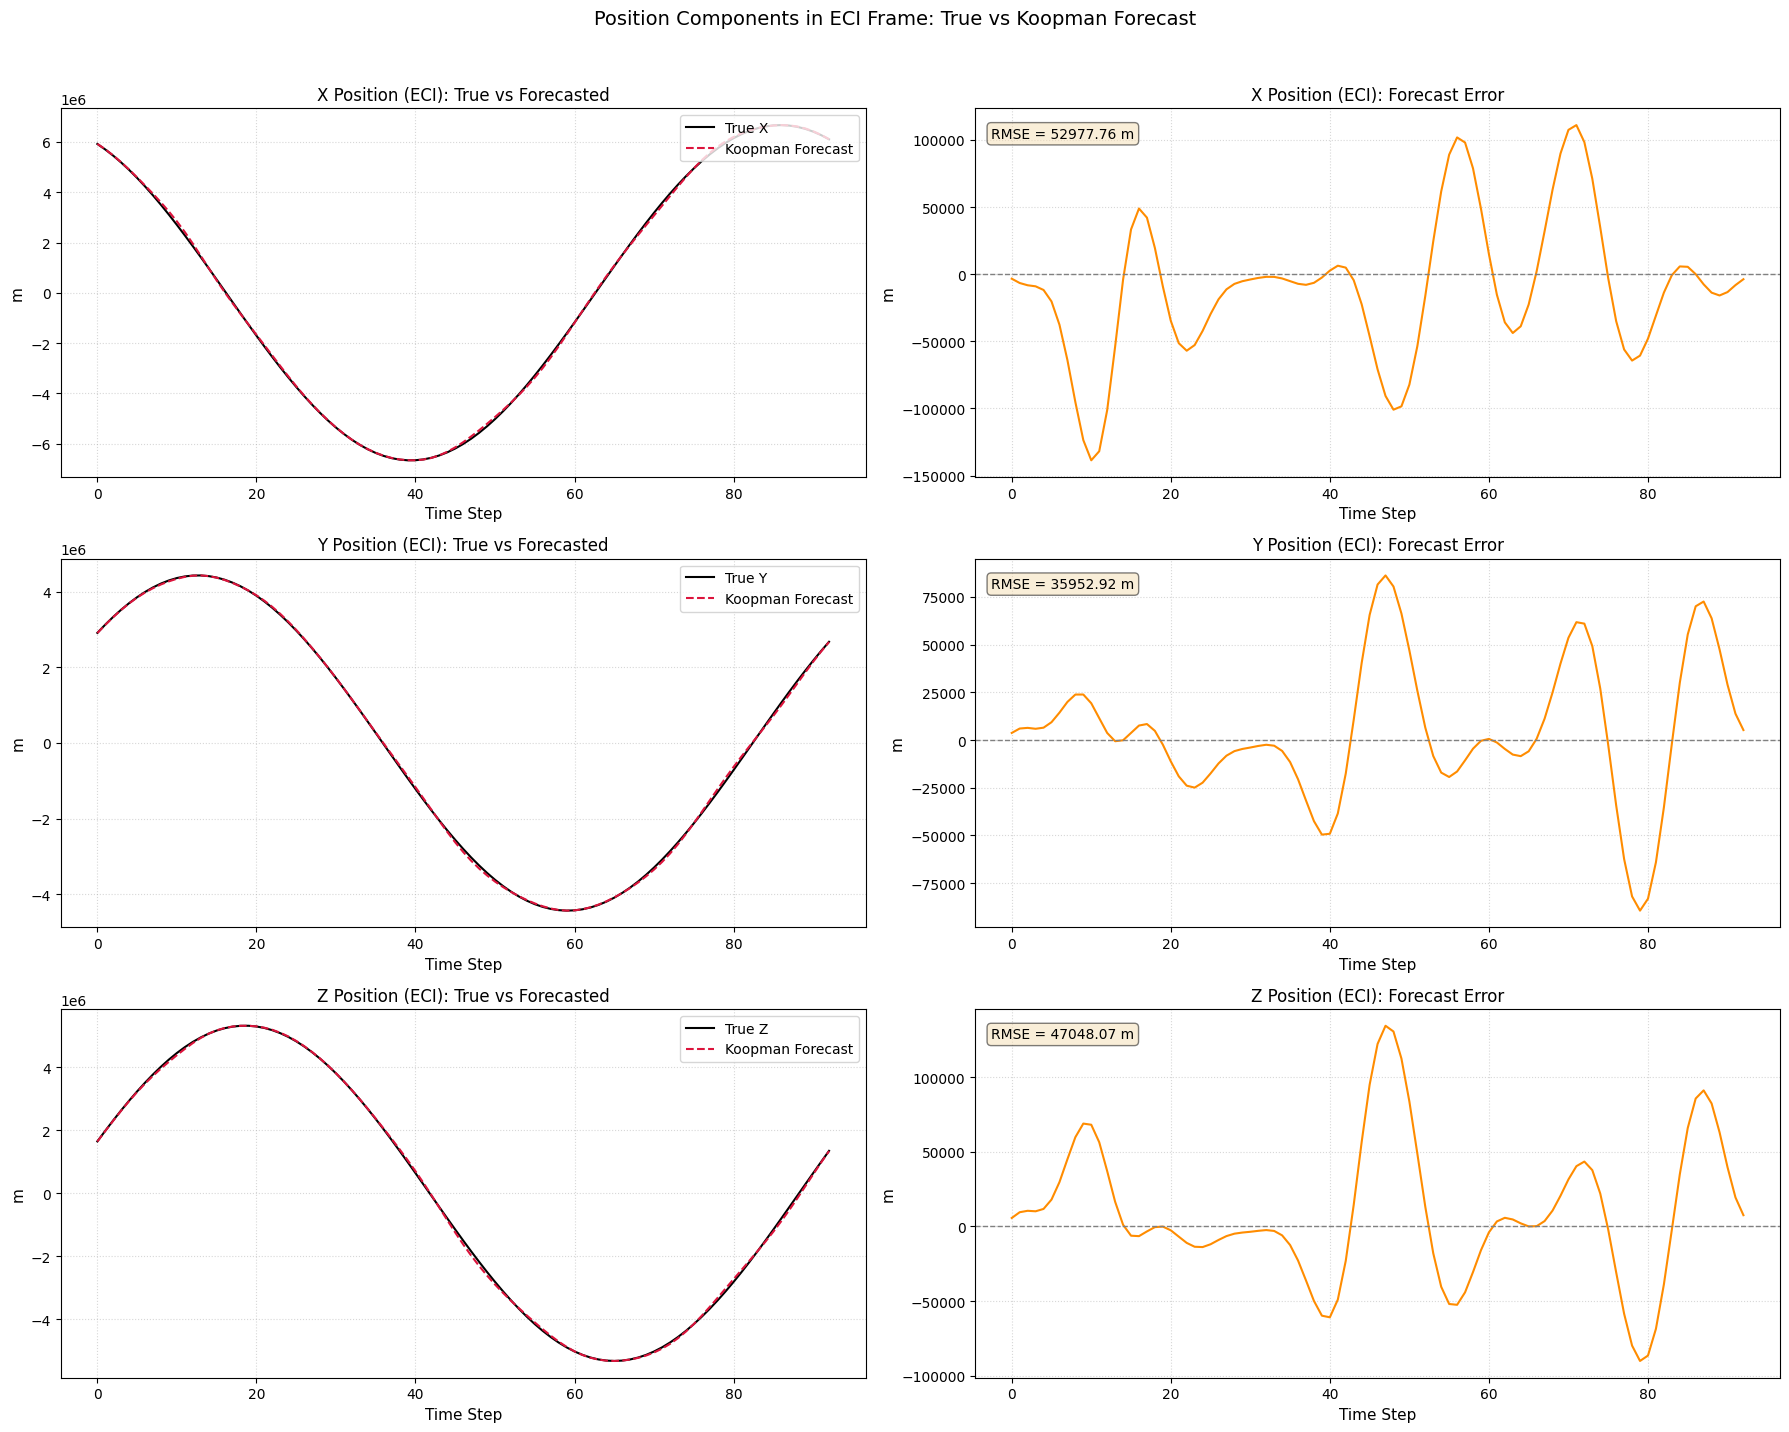

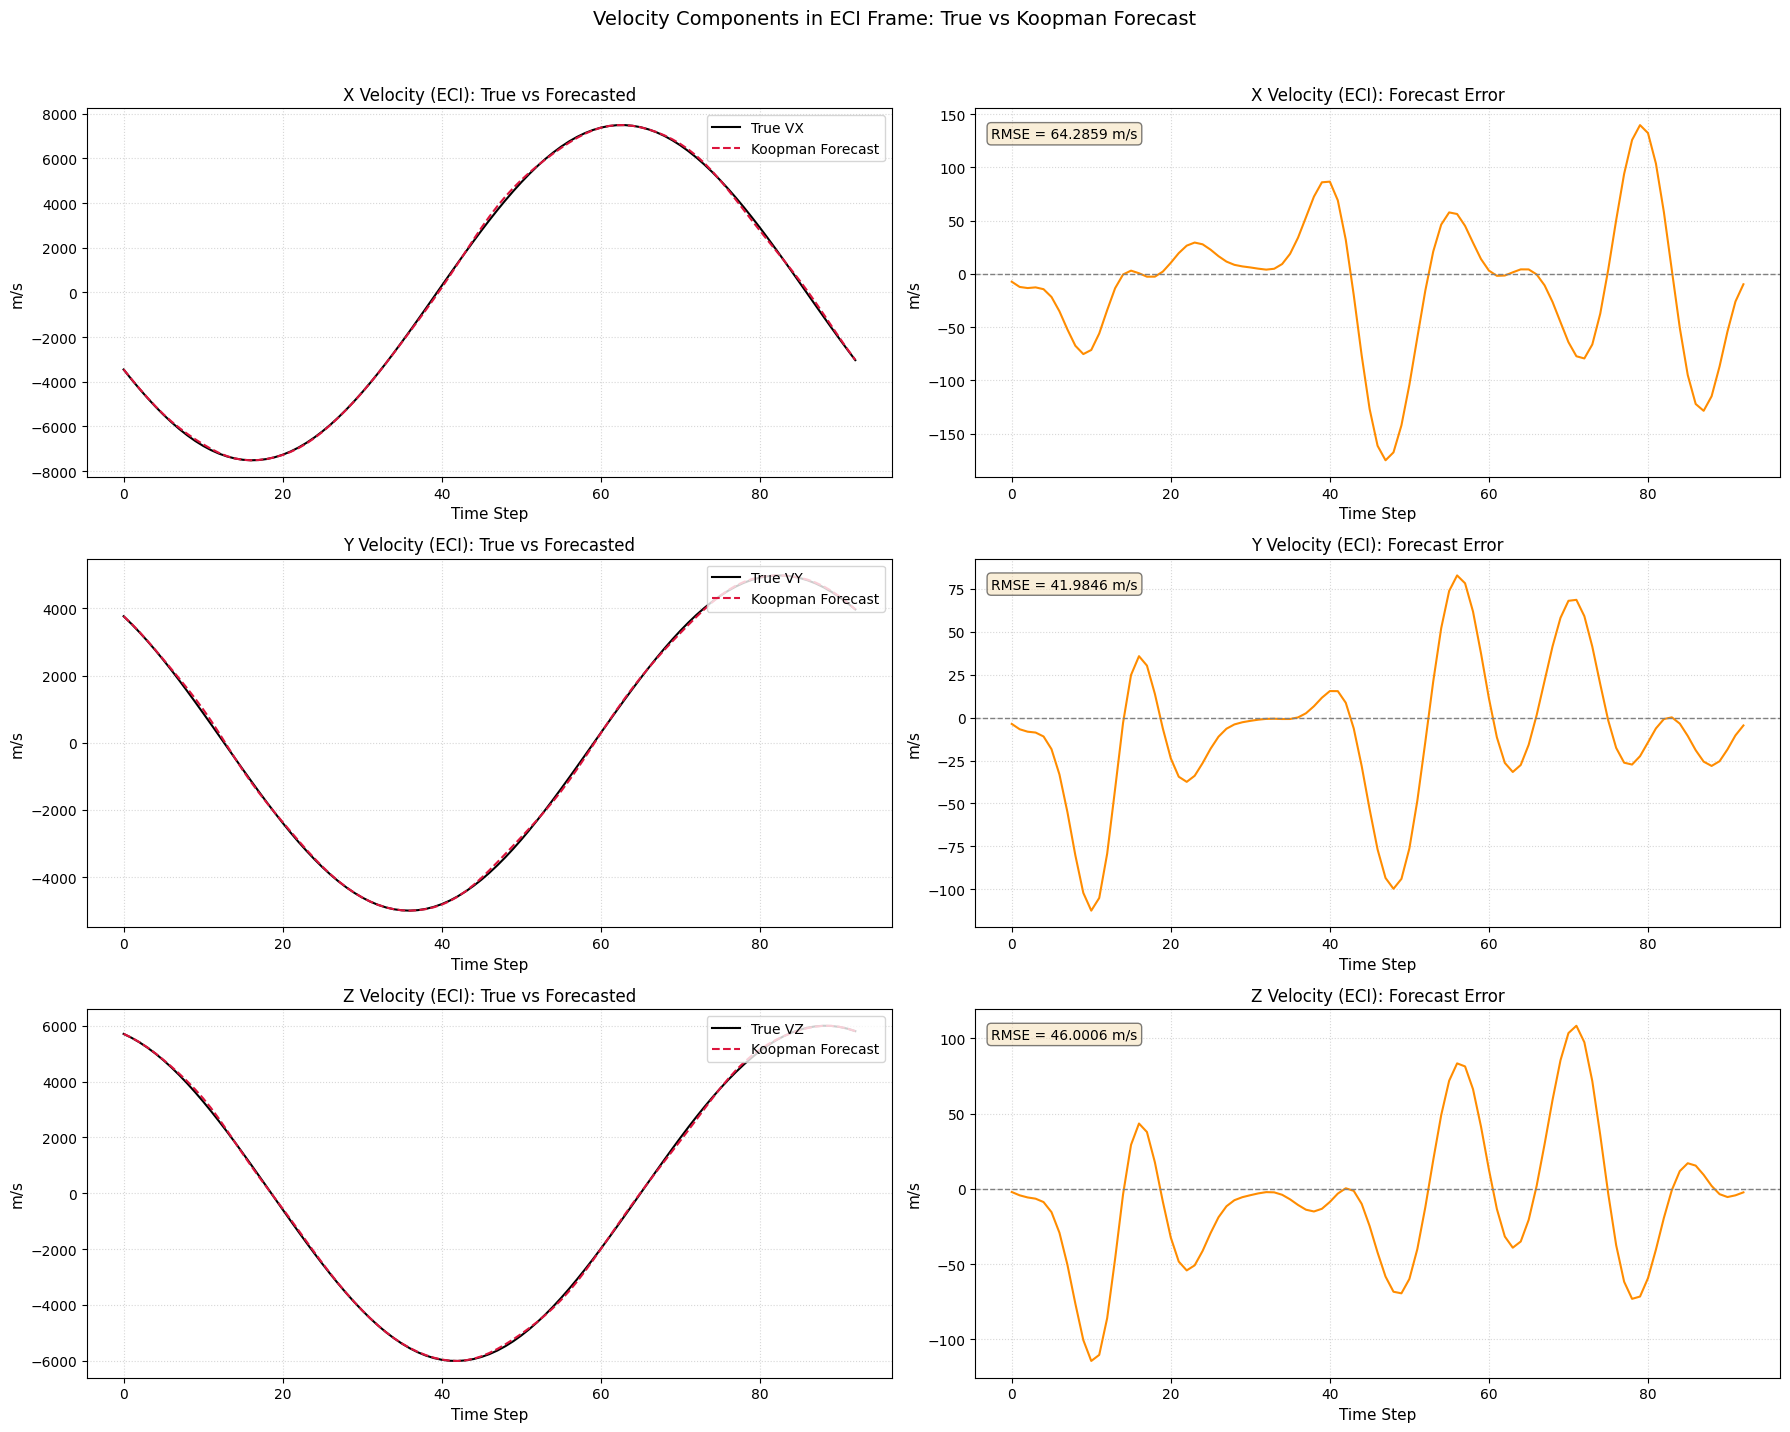

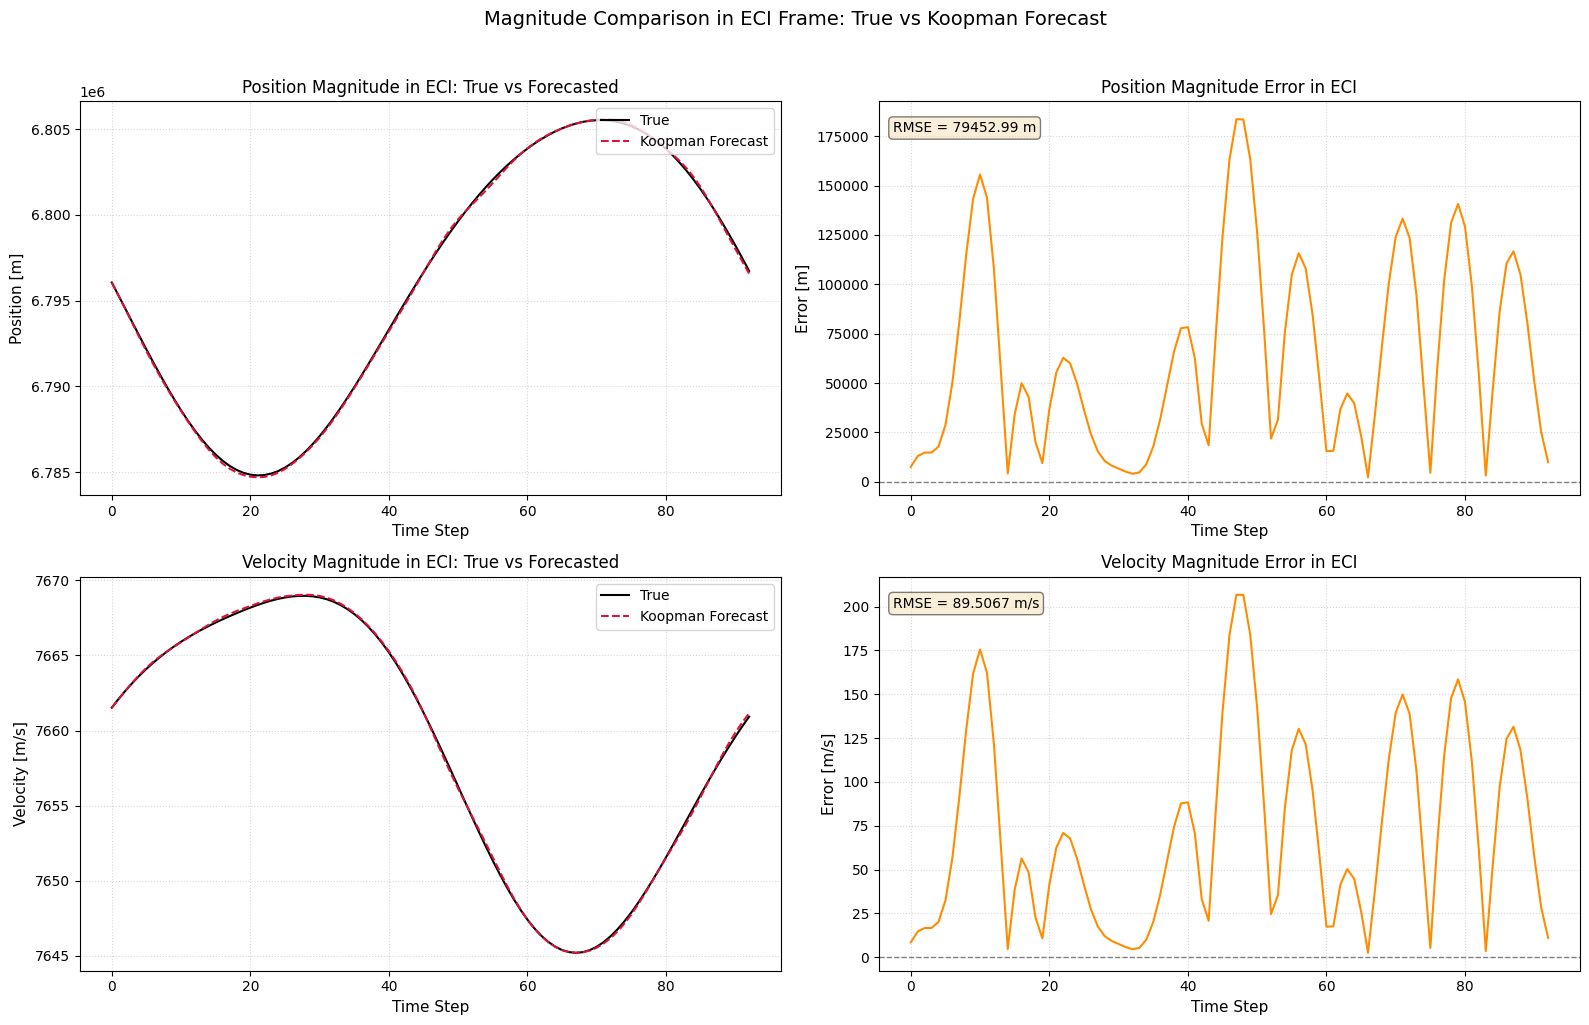


=== CARTESIAN ANALYSIS IN ECI FRAME COMPLETE ===
All results are in the EME2000 (ECI) frame


In [3]:
# Keplerian to Cartesian Conversion in ECI
# ==============================================================================
# 11. CONVERT TO CARTESIAN COORDINATES USING OREKIT (ECI FRAME)
# ==============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# OREKIT IMPORTS (Hata vermemesi için try-except bloğuna alındı)
# ==============================================================================
try:
    import orekit
    from java.io import File
    from orekit import JArray
    from org.orekit.data import DataContext, DataProvidersManager, DirectoryCrawler
    from org.orekit.time import AbsoluteDate, TimeScalesFactory
    from org.orekit.frames import FramesFactory
    from org.orekit.orbits import KeplerianOrbit, PositionAngleType
    from org.orekit.utils import PVCoordinates
    OREKIT_IMPORTED = True
except ImportError as e:
    print(f"Orekit/Java kütüphaneleri bulunamadı: {e}")
    OREKIT_IMPORTED = False

# ==============================================================================
# OREKIT INITIALIZATION
# ==============================================================================

def init_orekit():
    """Initialize Orekit with data files."""
    if not OREKIT_IMPORTED:
        return False
        
    try:
        # Orekit için Java Sanal Makinesini (JVM) başlatmak zorunludur
        orekit.initVM()
        
        # Check for orekit-data directory
        orekit_data_dir = "orekit-data"
        if not os.path.exists(orekit_data_dir):
            print(f"WARNING: '{orekit_data_dir}' directory not found!")
            print("Please download orekit data from:")
            print("https://gitlab.orekit.org/orekit/orekit-data/-/archive/master/orekit-data-master.zip")
            print("Extract to './orekit-data/'")
            return False
        
        # Initialize Orekit data providers
        data_providers_manager = DataProvidersManager.getInstance()
        data_providers_manager.clearProviders()
        
        # Add data directory
        data_providers_manager.addProvider(DirectoryCrawler(File(orekit_data_dir)))
        
        print("✓ Orekit initialized successfully!")
        print(f"  Data directory: {os.path.abspath(orekit_data_dir)}")
        return True
        
    except Exception as e:
        print(f"ERROR initializing Orekit: {e}")
        return False

# Initialize Orekit
orekit_available = init_orekit()

if not orekit_available:
    print("\nFalling back to pure numpy implementation...")
    # Fallback to numpy implementation for ECI
    def kepler_to_cartesian_numpy_eci(a, e, i, omega, raan, m, mu=3.986004418e14):
        """
        Convert Keplerian orbital elements to Cartesian position and velocity in ECI.
        Pure numpy implementation (fallback if Orekit is unavailable).
        """
        # Solve Kepler's equation for eccentric anomaly E
        E = m
        for _ in range(20):
            dE = (E - e * np.sin(E) - m) / (1 - e * np.cos(E))
            E = E - dE
            if np.abs(dE) < 1e-12:
                break
        
        # Position and velocity in perifocal frame (PQW)
        p = a * (1 - e**2)
        r_norm = p / (1 + e * np.cos(E))
        
        # Position in perifocal frame
        x_peri = r_norm * np.cos(E)
        y_peri = r_norm * np.sin(E)
        z_peri = 0.0
        
        # Velocity in perifocal frame
        v_const = np.sqrt(mu / p)
        vx_peri = -v_const * np.sin(E)
        vy_peri = v_const * (e + np.cos(E))
        vz_peri = 0.0
        
        # Rotation from perifocal to ECI frame
        # Using the standard 3-1-3 rotation sequence: R3(-raan) * R1(-i) * R3(-omega)
        cos_raan = np.cos(raan)
        sin_raan = np.sin(raan)
        cos_i = np.cos(i)
        sin_i = np.sin(i)
        cos_omega = np.cos(omega)
        sin_omega = np.sin(omega)
        
        # Position transformation (PQW to ECI)
        x = (cos_omega * cos_raan - sin_omega * cos_i * sin_raan) * x_peri + (-sin_omega * cos_raan - cos_omega * cos_i * sin_raan) * y_peri
        y = (cos_omega * sin_raan + sin_omega * cos_i * cos_raan) * x_peri + (-sin_omega * sin_raan + cos_omega * cos_i * cos_raan) * y_peri
        z = sin_i * sin_omega * x_peri + sin_i * cos_omega * y_peri
        
        # Velocity transformation (same rotation applies)
        vx = (cos_omega * cos_raan - sin_omega * cos_i * sin_raan) * vx_peri + (-sin_omega * cos_raan - cos_omega * cos_i * sin_raan) * vy_peri
        vy = (cos_omega * sin_raan + sin_omega * cos_i * cos_raan) * vx_peri + (-sin_omega * sin_raan + cos_omega * cos_i * cos_raan) * vy_peri
        vz = sin_i * sin_omega * vx_peri + sin_i * cos_omega * vy_peri
        
        return np.array([x, y, z]), np.array([vx, vy, vz])
    
    orbital_to_cartesian = kepler_to_cartesian_numpy_eci
    print("Using pure numpy ECI conversion\n")

else:
    # Get reference frames and time scales
    # EME2000 is the standard ECI frame (Earth Mean Equator and Equinox of J2000)
    eci_frame = FramesFactory.getEME2000()
    utc = TimeScalesFactory.getUTC()
    
    # Reference date (fixed epoch for conversion)
    # Using J2000 epoch for consistency
    reference_date = AbsoluteDate(2000, 1, 1, 12, 0, 0, utc)
    
    def orbital_to_cartesian_orekit_eci(a, e, i, omega, raan, m, mu=3.986004418e14):
        """
        Convert orbital elements to Cartesian position and velocity in ECI frame using Orekit.
        """
        try:
            # Create Keplerian orbit in Orekit using ECI frame
            orbit = KeplerianOrbit(
                float(a),              # semi-major axis (m)
                float(e),              # eccentricity
                float(i),              # inclination (rad)
                float(omega),          # argument of perigee (rad)
                float(raan),           # RAAN (rad)
                float(m),              # mean anomaly (rad)
                PositionAngleType.MEAN,
                eci_frame,             # ECI frame (EME2000)
                reference_date,        # reference epoch
                mu                     # gravitational parameter
            )
            
            # Get Cartesian coordinates in ECI frame
            pv = orbit.getPVCoordinates(eci_frame)
            position = pv.getPosition()
            velocity = pv.getVelocity()
            
            # Return as numpy arrays
            return np.array([position.getX(), position.getY(), position.getZ()]), \
                   np.array([velocity.getX(), velocity.getY(), velocity.getZ()])
                   
        except Exception as e:
            print(f"Orekit conversion error: {e}")
            return None, None
    
    orbital_to_cartesian = orbital_to_cartesian_orekit_eci
    print("Using Orekit for orbital-to-Cartesian conversion in ECI frame\n")

print("=== CONVERTING TO CARTESIAN COORDINATES (ECI FRAME) ===")

# Convert true orbital elements to Cartesian
true_positions = []
true_velocities = []

print("Converting true orbital elements...")
for idx in range(len(true_raw_future)):
    if idx % 50 == 0:
        print(f"  Progress: {idx}/{len(true_raw_future)}")
    
    a = true_raw_future['a'].iloc[idx]
    e = true_raw_future['e'].iloc[idx]
    i = true_raw_future['i'].iloc[idx]
    omega = true_raw_future['omega'].iloc[idx]
    raan = true_raw_future['raan'].iloc[idx]
    m = true_raw_future['m'].iloc[idx]
    
    pos, vel = orbital_to_cartesian(a, e, i, omega, raan, m)
    if pos is None:  # If Orekit failed
        # Fallback to numpy for this specific case
        pos, vel = kepler_to_cartesian_numpy_eci(a, e, i, omega, raan, m)
    true_positions.append(pos)
    true_velocities.append(vel)

true_positions = np.array(true_positions)
true_velocities = np.array(true_velocities)

# Convert predicted orbital elements to Cartesian
pred_positions = []
pred_velocities = []

print("Converting predicted orbital elements...")
for idx in range(len(pred_raw_future)):
    if idx % 50 == 0:
        print(f"  Progress: {idx}/{len(pred_raw_future)}")
    
    a = pred_raw_future['a'].iloc[idx]
    e = pred_raw_future['e'].iloc[idx]
    i = pred_raw_future['i'].iloc[idx]
    omega = pred_raw_future['omega'].iloc[idx]
    raan = pred_raw_future['raan'].iloc[idx]
    m = pred_raw_future['m'].iloc[idx]
    
    pos, vel = orbital_to_cartesian(a, e, i, omega, raan, m)
    if pos is None:  # If Orekit failed
        # Fallback to numpy for this specific case
        pos, vel = kepler_to_cartesian_numpy_eci(a, e, i, omega, raan, m)
    pred_positions.append(pos)
    pred_velocities.append(vel)

pred_positions = np.array(pred_positions)
pred_velocities = np.array(pred_velocities)

print(f"\n✓ Conversion complete!")
print(f"  True positions shape: {true_positions.shape}")
print(f"  Predicted positions shape: {pred_positions.shape}")
print(f"  Frame: ECI (EME2000)")

# ==============================================================================
# 12. CARTESIAN COORDINATE ERRORS IN ECI
# ==============================================================================

# Position errors (in meters) in ECI frame
pos_errors = true_positions - pred_positions
pos_error_magnitudes = np.linalg.norm(pos_errors, axis=1)

# Velocity errors (in m/s) in ECI frame
vel_errors = true_velocities - pred_velocities
vel_error_magnitudes = np.linalg.norm(vel_errors, axis=1)

# Position component errors
pos_error_df = pd.DataFrame(pos_errors, columns=['dx', 'dy', 'dz'])
vel_error_df = pd.DataFrame(vel_errors, columns=['dvx', 'dvy', 'dvz'])

print("=== CARTESIAN ERROR SUMMARY (ECI FRAME) ===")
print("\nPosition Errors (meters) in ECI:")
for idx, coord in enumerate(['x', 'y', 'z']):
    rmse = np.sqrt(np.mean(pos_errors[:, idx]**2))
    mae = np.mean(np.abs(pos_errors[:, idx]))
    max_error = np.max(np.abs(pos_errors[:, idx]))
    print(f"  {coord}: RMSE = {rmse:.2f} m, MAE = {mae:.2f} m, Max = {max_error:.2f} m")

rmse_pos_mag = np.sqrt(np.mean(pos_error_magnitudes**2))
mae_pos_mag = np.mean(pos_error_magnitudes)
max_pos_mag = np.max(pos_error_magnitudes)
print(f"  Magnitude: RMSE = {rmse_pos_mag:.2f} m, MAE = {mae_pos_mag:.2f} m, Max = {max_pos_mag:.2f} m")

print("\nVelocity Errors (m/s) in ECI:")
for idx, coord in enumerate(['vx', 'vy', 'vz']):
    rmse = np.sqrt(np.mean(vel_errors[:, idx]**2))
    mae = np.mean(np.abs(vel_errors[:, idx]))
    max_error = np.max(np.abs(vel_errors[:, idx]))
    print(f"  {coord}: RMSE = {rmse:.4f} m/s, MAE = {mae:.4f} m/s, Max = {max_error:.4f} m/s")

rmse_vel_mag = np.sqrt(np.mean(vel_error_magnitudes**2))
mae_vel_mag = np.mean(vel_error_magnitudes)
max_vel_mag = np.max(vel_error_magnitudes)
print(f"  Magnitude: RMSE = {rmse_vel_mag:.4f} m/s, MAE = {mae_vel_mag:.4f} m/s, Max = {max_vel_mag:.4f} m/s")

# ==============================================================================
# 13. PLOT CARTESIAN RESULTS IN ECI
# ==============================================================================

cartesian_labels = {
    'x': {'title': 'X Position (ECI)', 'unit': 'm', 'error_unit': 'm'},
    'y': {'title': 'Y Position (ECI)', 'unit': 'm', 'error_unit': 'm'},
    'z': {'title': 'Z Position (ECI)', 'unit': 'm', 'error_unit': 'm'},
    'vx': {'title': 'X Velocity (ECI)', 'unit': 'm/s', 'error_unit': 'm/s'},
    'vy': {'title': 'Y Velocity (ECI)', 'unit': 'm/s', 'error_unit': 'm/s'},
    'vz': {'title': 'Z Velocity (ECI)', 'unit': 'm/s', 'error_unit': 'm/s'},
}

# Create figure for position components
fig1, axes1 = plt.subplots(3, 2, figsize=(18, 14))
for idx, coord in enumerate(['x', 'y', 'z']):
    true_vals = true_positions[:, idx]
    pred_vals = pred_positions[:, idx]
    error_vals = pos_errors[:, idx]
    
    # Left: True vs Predicted
    ax_comp = axes1[idx, 0]
    ax_comp.plot(true_vals, label=f"True {coord.upper()}", color="black", linewidth=1.5)
    ax_comp.plot(pred_vals, "--", label="Koopman Forecast", color="crimson", linewidth=1.5)
    ax_comp.set_title(f"{cartesian_labels[coord]['title']}: True vs Forecasted", fontsize=12)
    ax_comp.set_ylabel(cartesian_labels[coord]['unit'], fontsize=11)
    ax_comp.set_xlabel("Time Step", fontsize=11)
    ax_comp.grid(True, linestyle=":", alpha=0.5)
    ax_comp.legend(loc="upper right")
    
    # Right: Error
    ax_err = axes1[idx, 1]
    ax_err.plot(error_vals, color="darkorange", linewidth=1.5)
    ax_err.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_err.set_title(f"{cartesian_labels[coord]['title']}: Forecast Error", fontsize=12)
    ax_err.set_ylabel(cartesian_labels[coord]['error_unit'], fontsize=11)
    ax_err.set_xlabel("Time Step", fontsize=11)
    ax_err.grid(True, linestyle=":", alpha=0.5)
    
    # Add RMSE annotation
    rmse_val = np.sqrt(np.mean(error_vals**2))
    ax_err.text(0.02, 0.95, f"RMSE = {rmse_val:.2f} {cartesian_labels[coord]['unit']}", 
                transform=ax_err.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Position Components in ECI Frame: True vs Koopman Forecast", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Create figure for velocity components
fig2, axes2 = plt.subplots(3, 2, figsize=(18, 14))
for idx, coord in enumerate(['vx', 'vy', 'vz']):
    true_vals = true_velocities[:, idx]
    pred_vals = pred_velocities[:, idx]
    error_vals = vel_errors[:, idx]
    
    # Left: True vs Predicted
    ax_comp = axes2[idx, 0]
    ax_comp.plot(true_vals, label=f"True {coord.upper()}", color="black", linewidth=1.5)
    ax_comp.plot(pred_vals, "--", label="Koopman Forecast", color="crimson", linewidth=1.5)
    ax_comp.set_title(f"{cartesian_labels[coord]['title']}: True vs Forecasted", fontsize=12)
    ax_comp.set_ylabel(cartesian_labels[coord]['unit'], fontsize=11)
    ax_comp.set_xlabel("Time Step", fontsize=11)
    ax_comp.grid(True, linestyle=":", alpha=0.5)
    ax_comp.legend(loc="upper right")
    
    # Right: Error
    ax_err = axes2[idx, 1]
    ax_err.plot(error_vals, color="darkorange", linewidth=1.5)
    ax_err.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax_err.set_title(f"{cartesian_labels[coord]['title']}: Forecast Error", fontsize=12)
    ax_err.set_ylabel(cartesian_labels[coord]['error_unit'], fontsize=11)
    ax_err.set_xlabel("Time Step", fontsize=11)
    ax_err.grid(True, linestyle=":", alpha=0.5)
    
    # Add RMSE annotation
    rmse_val = np.sqrt(np.mean(error_vals**2))
    ax_err.text(0.02, 0.95, f"RMSE = {rmse_val:.4f} {cartesian_labels[coord]['unit']}", 
                transform=ax_err.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Velocity Components in ECI Frame: True vs Koopman Forecast", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================================================
# 14. MAGNITUDE PLOTS IN ECI
# ==============================================================================

fig3, axes3 = plt.subplots(2, 2, figsize=(16, 10))

# Position magnitude
true_pos_mag = np.linalg.norm(true_positions, axis=1)
pred_pos_mag = np.linalg.norm(pred_positions, axis=1)
error_pos_mag = pos_error_magnitudes

ax_pos_mag = axes3[0, 0]
ax_pos_mag.plot(true_pos_mag, label="True", color="black", linewidth=1.5)
ax_pos_mag.plot(pred_pos_mag, "--", label="Koopman Forecast", color="crimson", linewidth=1.5)
ax_pos_mag.set_title("Position Magnitude in ECI: True vs Forecasted", fontsize=12)
ax_pos_mag.set_ylabel("Position [m]", fontsize=11)
ax_pos_mag.set_xlabel("Time Step", fontsize=11)
ax_pos_mag.grid(True, linestyle=":", alpha=0.5)
ax_pos_mag.legend(loc="upper right")

# Position magnitude error
ax_pos_err = axes3[0, 1]
ax_pos_err.plot(error_pos_mag, color="darkorange", linewidth=1.5)
ax_pos_err.axhline(0, color="gray", linestyle="--", linewidth=1)
ax_pos_err.set_title("Position Magnitude Error in ECI", fontsize=12)
ax_pos_err.set_ylabel("Error [m]", fontsize=11)
ax_pos_err.set_xlabel("Time Step", fontsize=11)
ax_pos_err.grid(True, linestyle=":", alpha=0.5)
rmse_pos = np.sqrt(np.mean(error_pos_mag**2))
ax_pos_err.text(0.02, 0.95, f"RMSE = {rmse_pos:.2f} m", 
                transform=ax_pos_err.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Velocity magnitude
true_vel_mag = np.linalg.norm(true_velocities, axis=1)
pred_vel_mag = np.linalg.norm(pred_velocities, axis=1)
error_vel_mag = vel_error_magnitudes

ax_vel_mag = axes3[1, 0]
ax_vel_mag.plot(true_vel_mag, label="True", color="black", linewidth=1.5)
ax_vel_mag.plot(pred_vel_mag, "--", label="Koopman Forecast", color="crimson", linewidth=1.5)
ax_vel_mag.set_title("Velocity Magnitude in ECI: True vs Forecasted", fontsize=12)
ax_vel_mag.set_ylabel("Velocity [m/s]", fontsize=11)
ax_vel_mag.set_xlabel("Time Step", fontsize=11)
ax_vel_mag.grid(True, linestyle=":", alpha=0.5)
ax_vel_mag.legend(loc="upper right")

# Velocity magnitude error
ax_vel_err = axes3[1, 1]
ax_vel_err.plot(error_vel_mag, color="darkorange", linewidth=1.5)
ax_vel_err.axhline(0, color="gray", linestyle="--", linewidth=1)
ax_vel_err.set_title("Velocity Magnitude Error in ECI", fontsize=12)
ax_vel_err.set_ylabel("Error [m/s]", fontsize=11)
ax_vel_err.set_xlabel("Time Step", fontsize=11)
ax_vel_err.grid(True, linestyle=":", alpha=0.5)
rmse_vel = np.sqrt(np.mean(error_vel_mag**2))
ax_vel_err.text(0.02, 0.95, f"RMSE = {rmse_vel:.4f} m/s", 
                transform=ax_vel_err.transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("Magnitude Comparison in ECI Frame: True vs Koopman Forecast", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== CARTESIAN ANALYSIS IN ECI FRAME COMPLETE ===")
print(f"All results are in the EME2000 (ECI) frame")